# WDC-PAVE Dataset - Exploratory Data Analysis

The [WDC Product Attribute Value Extraction (PAVE)](https://webdatacommons.org/structureddata/2022-12/WDCPave.html) benchmark contains product offers with attribute-value annotations.

**Files:**
- `final_target_scores.jsonl` - Original target scores
- `normalized_target_scores.jsonl` - Normalized target scores

In [1]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd

DATA_DIR = Path("../data/WDC-PAVE")

## 1. Load data

In [2]:
def load_jsonl(path: Path) -> list[dict]:
    with open(path) as f:
        return [json.loads(line) for line in f]

final = load_jsonl(DATA_DIR / "final_target_scores.jsonl")
normalized = load_jsonl(DATA_DIR / "normalized_target_scores.jsonl")

print(f"final_target_scores:      {len(final):,} records")
print(f"normalized_target_scores: {len(normalized):,} records")

final_target_scores:      1,420 records
normalized_target_scores: 1,420 records


## 2. Schema overview

In [3]:
sample = normalized[0]
print("Top-level keys:", list(sample.keys()))
print()
for k, v in sample.items():
    if k != "target_scores":
        print(f"  {k}: {type(v).__name__} -> {repr(v)[:120]}")

print("\ntarget_scores attributes:", list(sample["target_scores"].keys()))

Top-level keys: ['id', 'cluster_id', 'category', 'input_title', 'input_description', 'target_scores', 'url']

  id: int -> 7230884
  cluster_id: float -> 14208681.0
  category: str -> 'Computers And Accessories'
  input_title: str -> '435952-B21 HP Xeon E5335 2.0GHz DL360 G5" Null'
  input_description: str -> 'Description:Intel Xeon E5335 DL360 G5(2.0GHz/4-core/8MB-2x4MB/80W)Full Processor Option KitPart Number(s) Part# 435952-
  url: str -> 'www.harddrivesdirect.com'

target_scores attributes: ['Generation', 'Part Number', 'Product Type', 'Cache', 'Processor Type', 'Processor Core', 'Interface', 'Manufacturer', 'Capacity', 'Ports', 'Rotational Speed']


In [4]:
# Compare schemas between the two files
final_keys = set()
norm_keys = set()
final_attrs = set()
norm_attrs = set()

for rec in final:
    final_keys.update(rec.keys())
    final_attrs.update(rec["target_scores"].keys())

for rec in normalized:
    norm_keys.update(rec.keys())
    norm_attrs.update(rec["target_scores"].keys())

print("Top-level keys — final only:", final_keys - norm_keys)
print("Top-level keys — norm only: ", norm_keys - final_keys)
print(f"\nAttributes in final:      {len(final_attrs)}")
print(f"Attributes in normalized: {len(norm_attrs)}")
print("Attrs in final only:", final_attrs - norm_attrs)
print("Attrs in norm only: ", norm_attrs - final_attrs)

Top-level keys — final only: set()
Top-level keys — norm only:  {'url'}

Attributes in final:      51
Attributes in normalized: 24
Attrs in final only: {'Page Yield', 'Shelves', 'Splash', 'Mounting', 'Stones Type', 'Bus Speed', 'Processor Quantity', 'Closure', 'Stones Setting', 'Flavor', 'Shape', 'Thermal Design Power', 'Clock Speed', 'Base', 'Stone Shape', 'Stainless Steel Series', 'Voltage', 'Stones Total Weight', 'Gauge', 'Cooling', 'Sheet Perforation', 'Metal Type', 'Heat', 'Packing Type', 'Gender', 'Binding', 'Material'}
Attrs in norm only:  set()


## 3. Category distribution

In [5]:
cat_counts = Counter(rec["category"] for rec in normalized)
cat_df = pd.DataFrame(cat_counts.most_common(), columns=["category", "count"])
cat_df["pct"] = (cat_df["count"] / cat_df["count"].sum() * 100).round(1)
cat_df

,category,count,pct
0,Computers And Accessories,436,30.7
1,Home And Garden,356,25.1
2,Office Products,297,20.9
3,Jewelry,250,17.6
4,Grocery And Gourmet Food,81,5.7


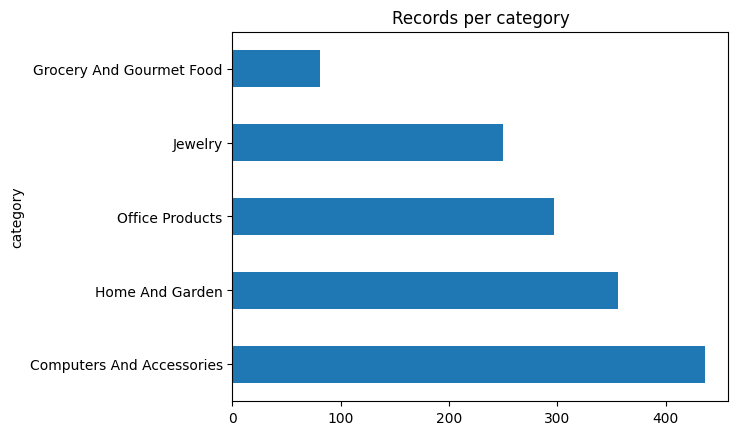

In [6]:
cat_df.plot.barh(x="category", y="count", legend=False, title="Records per category")
None  # suppress extra output

## 4. Attribute analysis

In [7]:
# How many attributes per record?
attr_counts = [len(rec["target_scores"]) for rec in normalized]
print(f"Attributes per record — min: {min(attr_counts)}, max: {max(attr_counts)}, "
      f"mean: {sum(attr_counts)/len(attr_counts):.1f}")

Attributes per record — min: 3, max: 11, mean: 8.3


In [8]:
# Most common attributes across all records
all_attrs = Counter()
for rec in normalized:
    all_attrs.update(rec["target_scores"].keys())

attr_df = pd.DataFrame(all_attrs.most_common(), columns=["attribute", "count"])
attr_df.head(20)

,attribute,count
0,Product Type,1420
1,Retail UPC,734
2,Manufacturer Stock Number,653
3,Length,653
4,Depth,653
5,Height,653
6,Width,653
7,Generation,436
8,Part Number,436
9,Cache,436


In [9]:
# Attributes per category
attrs_by_cat = {}
for rec in normalized:
    cat = rec["category"]
    attrs_by_cat.setdefault(cat, set()).update(rec["target_scores"].keys())

for cat, attrs in sorted(attrs_by_cat.items()):
    print(f"\n{cat} ({len(attrs)} attributes):")
    print(f"  {', '.join(sorted(attrs))}")


Computers And Accessories (11 attributes):
  Cache, Capacity, Generation, Interface, Manufacturer, Part Number, Ports, Processor Core, Processor Type, Product Type, Rotational Speed

Grocery And Gourmet Food (5 attributes):
  Brand, Pack Quantity, Product Type, Retail UPC, Size/Weight

Home And Garden (8 attributes):
  Color, Depth, Height, Length, Manufacturer Stock Number, Product Type, Retail UPC, Width

Jewelry (3 attributes):
  Brand, Model Number, Product Type

Office Products (10 attributes):
  Color(s), Depth, Height, Length, Manufacturer Stock Number, Pack Quantity, Paper Weight, Product Type, Retail UPC, Width


## 5. Target scores structure

Each attribute maps to possible values. A value is either `"n/a"` (not applicable) or a dict with `pid` (provenance IDs) and `score`.

In [10]:
# Count n/a vs. actual values per attribute
na_counts = Counter()
val_counts = Counter()

for rec in normalized:
    for attr, values in rec["target_scores"].items():
        for val, detail in values.items():
            if detail == "n/a" or val == "n/a":
                na_counts[attr] += 1
            else:
                val_counts[attr] += 1

na_vs_val = pd.DataFrame({
    "has_value": val_counts,
    "n/a": na_counts,
}).fillna(0).astype(int)
na_vs_val["fill_rate"] = (na_vs_val["has_value"] / (na_vs_val["has_value"] + na_vs_val["n/a"]) * 100).round(1)
na_vs_val.sort_values("fill_rate", ascending=False)

,has_value,n/a,fill_rate
Brand,337,0,100.0
Part Number,453,4,99.1
Product Type,1495,24,98.4
Manufacturer,585,15,97.5
Manufacturer Stock Number,626,38,94.3
Model Number,237,15,94.0
Color(s),308,35,89.8
Size/Weight,60,23,72.3
Width,433,237,64.6
Pack Quantity,256,151,62.9


## 6. Text length distributions

In [11]:
df = pd.DataFrame(normalized)
df["title_len"] = df["input_title"].str.len()
df["desc_len"] = df["input_description"].str.len()
df[["title_len", "desc_len"]].describe().round(0)

,title_len,desc_len
count,1420.0,1420.0
mean,83.0,307.0
std,29.0,215.0
min,17.0,29.0
25%,61.0,138.0
50%,90.0,247.0
75%,103.0,388.0
max,180.0,992.0


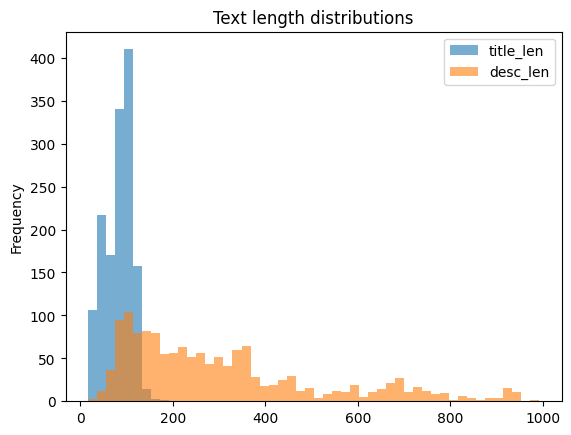

In [12]:
df[["title_len", "desc_len"]].plot.hist(bins=50, alpha=0.6, title="Text length distributions")
None

## 7. Cluster analysis

In [13]:
cluster_sizes = df["cluster_id"].value_counts()
print(f"Unique clusters: {cluster_sizes.shape[0]}")
print(f"Records per cluster — min: {cluster_sizes.min()}, max: {cluster_sizes.max()}, "
      f"mean: {cluster_sizes.mean():.1f}, median: {cluster_sizes.median():.0f}")
print(f"\nCluster size distribution:")
cluster_sizes.value_counts().sort_index()

Unique clusters: 1420
Records per cluster — min: 1, max: 1, mean: 1.0, median: 1

Cluster size distribution:


count
1    1420
Name: count, dtype: int64

## 8. Sample records

In [14]:
# Pretty-print a few records to inspect structure
for rec in normalized[:3]:
    print(f"ID: {rec['id']} | Category: {rec['category']}")
    print(f"Title: {rec['input_title'][:100]}...")
    print("Attributes:")
    for attr, values in rec["target_scores"].items():
        for val, detail in values.items():
            if detail != "n/a" and val != "n/a":
                print(f"  {attr}: {val} (score={detail['score']}, pid={detail['pid']})")
    print("-" * 80)

ID: 7230884 | Category: Computers And Accessories
Title: 435952-B21 HP Xeon E5335 2.0GHz DL360 G5" Null...
Attributes:
  Generation: Generation 5 (score=1, pid=[0, 1])
  Part Number: 435952B21 (score=1, pid=[0, 1])
  Product Type: Memory and Processing Upgrades (score=1, pid=[1])
  Cache: 8 Megabytes (score=1, pid=[1])
  Processor Type: Intel Xeon Series (score=1, pid=[0, 1])
  Processor Core: 4 (score=1, pid=[1])
  Manufacturer: Hewlett-Packard (score=1, pid=[0])
--------------------------------------------------------------------------------
ID: 3316138 | Category: Jewelry
Title: Benchmark Standard Comfort-Fit Wedding band LCF15018KW Shop Benchmark LCF15018KW bands | Midtown Jew...
Attributes:
  Product Type: Rings/Bands (score=1, pid=[0, 1])
  Brand: BENCHMARK (score=1, pid=[0, 1])
  Model Number: LCF15018KW (score=1, pid=[0])
--------------------------------------------------------------------------------
ID: 15126598 | Category: Computers And Accessories
Title: 314933-637 HP DL360